This week I want to investigate into why adding noise helps so much, and see if we can find some way, not to have to manually set a noise strength. I also want to look into variable timestepping, and equivariance.

We can analyze the forming of spurious osciallations by using spectral analysis. Suppose we have some function f (in this case our AI model), we input the current timestep $u_i$, so that $f(u_i) = u_{i+1}$ at some point the model will make a small mistake $\delta u$. We can linearize around u to get $f(u_i+\delta u) \approx f(u_i) + J\delta u$ with $J$ the jacobian at $u_i$. Repeatedly applying our model has the effect of multiplying $\delta u$ by powers of $J$. We then diagonalize $J$ and look at its eigenvalues. If the jacobian has eigenvalues with $|\lambda| > 1$, then the rollout can blow up if $\delta u$ has a component in the direction of the eigenvector corresponding to this eigenvalue. Knowing this, we expect a stable AI model to have eigenvalues smaller than 1. Lets now see how noise changes the eigenvalues of the jacobian.

We can see that adding noise shifts the eigenvalues of both models down. Now both models have a nice maximum eigenvalue of just below 1 (this is for a jacobian at u0, other timesteps give very similar results, although sometimes slightly larger than 1). We also see why the flux model was so unstable without adding noise, as it has many modes that will blow up.

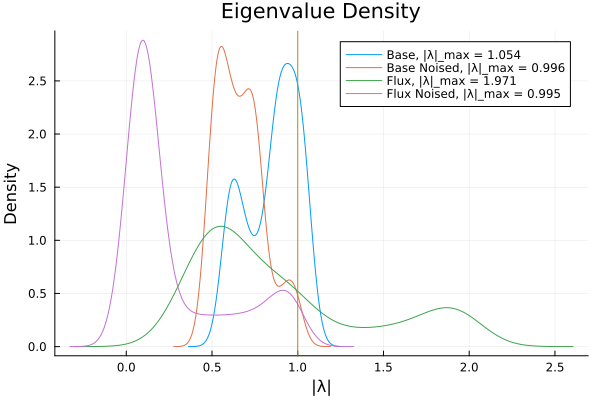

In [1]:
display("image/png", read("../media/spectrum_noise.png"))

I should note that these graphs change over time. The above graph is for t=0. Below is one of the density over time for the flux based model without noise.

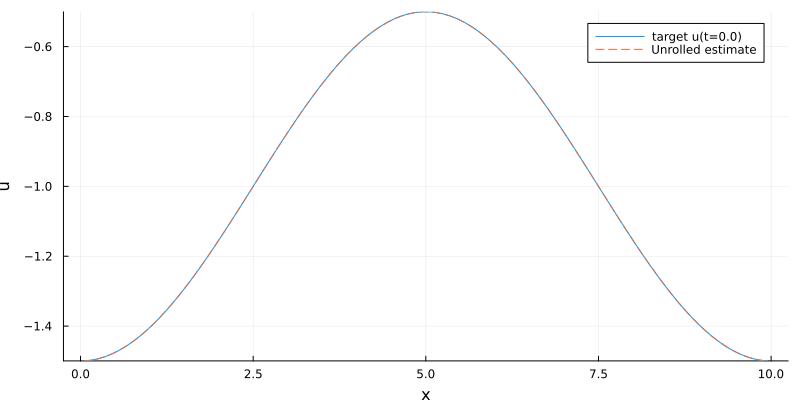

In [2]:
display("image/gif", read("../media/TEMP.gif"))

A cool thing that we can now do, is forcing a blow up in models with a largest eigenvalue bigger than 1. All we need to do is add a small $\delta u$ which is the eigenvector corresponding to the largest eigenvalue. We can compare this to a mode with a smaller eigenvalue.

It was quite hard to find an unstable model that didnt blow up by itself. A lot of times a model will have a large maximum eigenvalue at t=0, but smaller at later timesteps, which causes the mode to be supressed. In the second gif, we can also see that our small error caused a small oscillation at a later time, possibly by temporarily striking a high eigenvalue mode.

In [ ]:
display("image/gif", read("../media/forced_blowup.gif"))

In [ ]:
display("image/gif", read("../media/small_forced_blowup.gif"))

What we could now do, is add a loss function according to the largest eigenvalue in the jacobian. This would push the network to have jacobians with smaller eigenvalues in a natural way. The problem with this approach is that it is very expensive, as we need multiple forward passes on the network to get the largest eigenvalue. Even if we only need 5 forward passes to get the largest eigenvalue, that would still make training about 5 times as expensive. For now I will leave the noise as is. But atleast we now have a new powerful tool to analyse stability.

The models that we currently get are good. The model is able to unroll a wide arrange of different initial conditions. When I implement inductive bias in the model, I need to be able to see if the changes have made any effect. Therefore, if the model is too good, it will be harder to implement inductive bias. For this reason I will restrict the model by either reducing training data, layers, or training time. Below are a couple examples of the same model being able to unroll different initial conditions.

(the last gif is even tested on a frequency, and amplitude not in the training range, as well, as being a sin instead of a cos)

In [ ]:
display("image/gif", read("../media/ic_1.gif"))

In [ ]:
display("image/gif", read("../media/ic_2.gif"))

In [ ]:
display("image/gif", read("../media/ic_3.gif"))

In [ ]:
display("image/gif", read("../media/ic_4.gif"))

In [ ]:
display("image/gif", read("../media/ic_5.gif"))

In [ ]:
display("image/gif", read("../media/ic_6.gif"))

## intermission

The second thing I want to do this week is look into variable timestepping. One obvious approach is to add the desired $\Delta t$ as an extra channel to the model, however, this is rather clunky and probably inefficient. We only care about a global constant, so adding a whole channel with the same size as u is weird. We would also get practical problems with rollouts. If we make a model that always only outputs the next timestep, then we would have to re-add the timestep channel after every prediction. If we make the model always output 2 channels, then the timestep channel might change over time, which would also be weird, as we still want the same timestep. The solution that I will be exploring is the FiLM method, which implements two smaller functions (read MLPs) that take $\Delta t$ and are used as an affine transformation of intermediate features.

Here I train the model on a range of $\Delta t$. I then test the model on a wider range of $\Delta t$, and measure the mean error over 15 seconds. I added the FiLM layers to both the base model, and the flux based model, and I compare them against eachother.

We can see that both models are able to do very well in the training range, and are also able to extrapolate to $\Delta t$ outside the training range pretty well.

In [ ]:
display("image/png", read("../media/time_range_comp.png"))

Would the accuracy be better if we extended the training range?

It seems so. The accuracy inside the training range is also even better than before.

In [ ]:
display("image/png", read("../media/time_range_comp_extend.png"))

## End of intermission

I reduce the number of parameters of the model from 457 to 15 to artificially make the model a bit worse. The results that I get from this can be seen below.

In [ ]:
display("image/gif", read("../media/small_1.gif"))

In [ ]:
display("image/png", read("../media/small_1.png"))

In [ ]:
display("image/gif", read("../media/small_2.gif"))

In [ ]:
display("image/png", read("../media/small_2.png"))

In [ ]:
display("image/gif", read("../media/small_3.gif"))

In [ ]:
display("image/png", read("../media/small_3.png"))

In [ ]:
display("image/gif", read("../media/small_4.gif"))

In [ ]:
display("image/png", read("../media/small_4.png"))

In [ ]:
display("image/gif", read("../media/small_5.gif"))

In [ ]:
display("image/png", read("../media/small_5.png"))

The next big thing I want to do is force flip-reverse equivariance. To demonstrate this feature, I make two simulations, where one has a flipped and reversed initial condition compared to the other. After the simulation is complete, I again reflip and rereverse the augmented solution to see that now both solutions are the same.

We can see the equivariance in action.

In [ ]:
display("image/gif", read("../media/flip_target.gif"))

Now we do the same thing to the model input and output. We feed two signals, with one the flipped and reversed version of the other. After rollout, we again flip and reverse this signal to see if equivariance holds. 

We now see that there is a clear difference between the two predicted solutions. Forcing the model to respect this equivariance is the goal of the upcoming week.

In [ ]:
display("image/gif", read("../media/flip_pred.gif"))

From my reading, forcing equivariance is usually done two ways. 1) soft enforcing: we use data augmentation to teach the model how to timestep both versions of the signal. 2) hard enforcing: we use a group convolutional neural network which has a baked in enforcing of a chosen group equivariance. Seeing as the goal of this project is to study inductive bias, I will implement the latter of these two methods. The big challange with group convolutional neural networks, is that it requires some group theory (which was not part of my previous studies), and that the resources are rather limited.